In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

In [3]:
gold = pd.read_csv('gld_price_data.csv')

In [4]:
gold.head()
#spx = capitalisation index of 500 company

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [5]:
gold.tail()

,Date,SPX,GLD,USO,SLV,EUR/USD
2285,5/8/2018,2671.919922,124.589996,14.0600,15.5100,1.186789
2286,5/9/2018,2697.790039,124.330002,14.3700,15.5300,1.184722
2287,5/10/2018,2723.070068,125.180000,14.4100,15.7400,1.191753
2288,5/14/2018,2730.129883,124.489998,14.3800,15.5600,1.193118
2289,5/16/2018,2725.780029,122.543800,14.4058,15.4542,1.182033


In [6]:
gold.shape #2290 rows and 6 cols

(2290, 6)

In [7]:
gold.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [8]:
#checking missing values
gold.isnull()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
2285,False,False,False,False,False,False
2286,False,False,False,False,False,False
2287,False,False,False,False,False,False
2288,False,False,False,False,False,False


In [10]:
gold.isnull().sum()

,0
Date,0
SPX,0
GLD,0
USO,0
SLV,0
EUR/USD,0


In [11]:
#statistical measures of the data

gold.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


In [15]:
#correlation :
  #positive correlation
  #negative correlation


In [27]:
correlation = gold.drop('Date', axis=1).corr()

In [22]:
#construct the heatmap to understand the correlation
plt.figure(figsize=(8,5))

#

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Axes: >

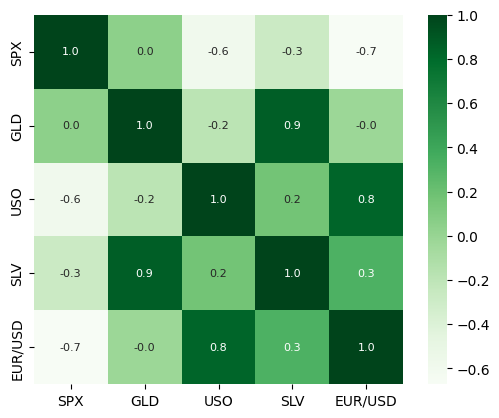

In [41]:
sns.heatmap(correlation,cbar=True,square=True,fmt='.1f',annot=True,annot_kws={'size':8},cmap='Greens')

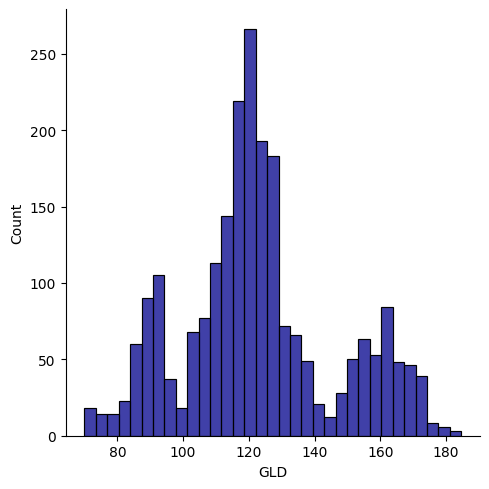

In [32]:
sns.displot(gold['GLD'], color='darkblue')

In [42]:
#splitting the features and targets

x = gold.drop(['Date','GLD'],axis=1)
y = gold['GLD']

In [43]:
print(y)

0        84.860001
1        85.570000
2        85.129997
3        84.769997
4        86.779999
           ...    
2285    124.589996
2286    124.330002
2287    125.180000
2288    124.489998
2289    122.543800
Name: GLD, Length: 2290, dtype: float64


In [44]:
#splitting into train and test data

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [45]:
#model training Random Forest Regressor
regressor = RandomForestRegressor(n_estimators=100)


In [46]:
regressor.fit(x_train,y_train) #training model

RandomForestRegressor()

In [47]:
#prediction on test data
test_data_pred = regressor.predict(x_test)

In [48]:
print(test_data_pred)

[168.3536995   82.05209978 116.03550042 127.63620058 120.79380125
 154.78309767 150.1546986  126.05150069 117.5889987  125.99990048
 116.66600086 171.29070081 142.03859868 167.78879862 115.07540006
 117.77150055 139.02560302 170.06990116 159.2070028  156.47839909
 154.90789971 125.36960026 175.52759955 157.09560291 125.29320035
  93.81229933  77.85040017 120.46439995 119.09819941 167.53870083
  88.41440065 125.18210036  91.21360083 117.59780035 121.07059903
 135.95970145 115.49420122 114.80110075 146.29489899 107.2305007
 104.43200262  87.18659774 126.66060036 117.9615998  152.8102991
 119.74470021 108.4084001  107.90819817  93.14180055 127.18829773
  74.86290052 113.66489917 121.37850034 111.25479937 119.00359895
 120.92039975 158.80590051 168.93620069 147.0191972   85.88269846
  94.34010041  86.82989874  90.51620018 118.92180062 126.41730063
 127.41110031 168.56669978 122.24599928 117.46769888  98.40480016
 168.52960105 143.00179785 131.96110249 121.13740213 120.9937997
 119.71610064

In [49]:
#r squred error

err_score = metrics.r2_score(y_test,test_data_pred)

In [50]:
print("R squared error: ",err_score)

R squared error:  0.9887079735890463


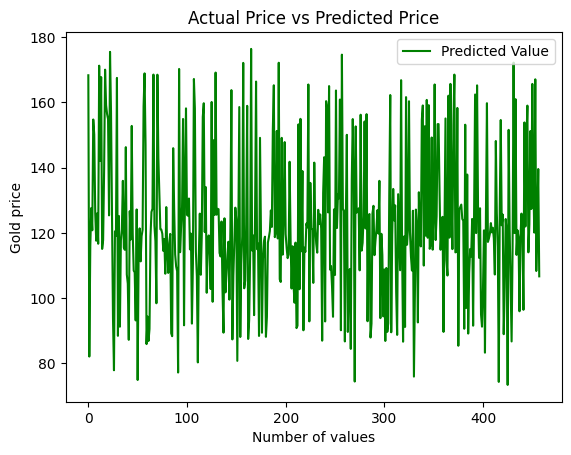

In [55]:
#compare actual values and predicted values a plot
#plt.plot(y_test,color='blue',label='Actual Value')
plt.plot(test_data_pred,color='green',label='Predicted Value')
plt.title('Actual Price vs Predicted Price')
plt.xlabel('Number of values')
plt.ylabel('Gold price')
plt.legend()
plt.show()